# Smart Textile for Invisible Movement
## Explainable AI-Based Postural-Risk Screening

**Research question.** *Can pressure distributions captured by a knitted smart textile be
transformed into an explainable machine-learning system for detecting potentially
undesirable postural patterns?*

**Secondary question.** *Which pressure-distribution characteristics contribute most
strongly to the model's decision?*

This notebook re-analyses the publicly available **Smart-Sleeve Dataset Based on Pressure
Mapping Smart Textile** (Xu, Deng & Cheng), pulling it **directly from GitHub into Kaggle**,
and builds a lightweight, explainable pipeline:

> **Smart knitted textile → pressure map → feature extraction → XGBoost → posture screening → SHAP explanation**

---

### ⚠️ Scientific scope and limitations (read first)
- This is an **AI re-analysis of an existing dataset**, *not* a textile-fabrication experiment.
- The dataset provides **activity/posture labels only** — it contains **no injury outcomes**.
- We therefore frame the task as **postural-risk *screening*** (detecting *potentially
  undesirable* posture), **never** as injury prediction, injury diagnosis, or clinical
  probability. No class is called "injury".
- The screening categories are a **documented, deterministic design mapping** built from the
  semantic meaning of the original 18 activity labels. They are a modelling construct, open to
  review — not a validated clinical instrument.
- No claim of clinical validation, real-time injury prediction, or injury prevention is made.


## Section 1 — Environment setup

We set random seeds for reproducibility and define one central `CONFIG` dictionary so every
important choice (label scheme, frame sub-sampling, split ratios, figure DPI) lives in one place.


In [1]:
# Install the two packages Kaggle may not ship by default (quiet).
import sys, subprocess
def _pip(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *pkgs], check=False)
_pip(["xgboost", "shap"])
print("Setup packages requested (xgboost, shap).")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 7.2 MB/s eta 0:00:00
Setup packages requested (xgboost, shap).


In [2]:
import os, re, json, glob, random, warnings, io, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110          # on-screen; saved figures use CONFIG['fig_dpi']
plt.rcParams["savefig.bbox"] = "tight"

# ----------------------------- Reproducibility -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------- Central configuration -----------------------
CONFIG = {
    "seed": SEED,
    # Screening task: "three_class" (recommended default) or "binary_quality".
    "screening_scheme": "three_class",
    # Keep every k-th frame inside a labelled segment (reduces heavy autocorrelation
    # and data size while staying at frame level). stride 4 at 50 Hz -> ~12.5 Hz.
    "frame_stride": 4,
    # Cap frames taken per labelled segment (None = no cap). Bounds runtime/memory.
    "max_frames_per_segment": 250,
    # Add simple WITHIN-segment temporal features (safe: order is reliable inside a segment).
    "include_temporal": True,
    # Subject-wise split ratios (applied over SUBJECTS, never over frames).
    "train_ratio": 0.70, "val_ratio": 0.15, "test_ratio": 0.15,
    # Figures.
    "fig_dpi": 300, "save_tiff": False,
    # SHAP: number of test rows sampled for speed.
    "shap_sample": 2000,
    # 12-bit ADC upper bound used for sanity clipping.
    "adc_max": 4095,
}
print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "screening_scheme": "three_class",
  "frame_stride": 4,
  "max_frames_per_segment": 250,
  "include_temporal": true,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "fig_dpi": 300,
  "save_tiff": false,
  "shap_sample": 2000,
  "adc_max": 4095
}


In [3]:
# ----------------------------- Output directory tree -----------------------
BASE_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.getcwd()
OUTPUT_ROOT = os.path.join(BASE_DIR, "smart_textile_postural_risk_output")
DIRS = {k: os.path.join(OUTPUT_ROOT, k)
        for k in ["figures", "results", "models", "data", "reports"]}
for d in [OUTPUT_ROOT, *DIRS.values()]:
    os.makedirs(d, exist_ok=True)

def save_fig(fig, name):
    "Save a figure as high-resolution PNG (and optional TIFF) into figures/."
    png = os.path.join(DIRS["figures"], name + ".png")
    fig.savefig(png, dpi=CONFIG["fig_dpi"])
    if CONFIG["save_tiff"]:
        fig.savefig(os.path.join(DIRS["figures"], name + ".tiff"),
                    dpi=max(CONFIG["fig_dpi"], 600))
    print("saved:", png)

print("Output tree created under:", OUTPUT_ROOT)
for k, v in DIRS.items():
    print(f"  {k:8s} -> {v}")


Output tree created under: /kaggle/working/smart_textile_postural_risk_output
  figures  -> /kaggle/working/smart_textile_postural_risk_output/figures
  results  -> /kaggle/working/smart_textile_postural_risk_output/results
  models   -> /kaggle/working/smart_textile_postural_risk_output/models
  data     -> /kaggle/working/smart_textile_postural_risk_output/data
  reports  -> /kaggle/working/smart_textile_postural_risk_output/reports


## Section 2 — Dataset download (GitHub → Kaggle)

The repository stores **140 `data.csv` + 140 `labels.csv` files** across
`subject_1..14 / round 1..10`. Downloading them one by one is tedious, so we pull the whole
repository **directly from GitHub**.

Primary method: a shallow `git clone`. Fallback: download the branch ZIP from `codeload`.

> **If this cell fails**, Kaggle Internet is probably off. Turn it on via the right-hand panel:
> **Notebook → Settings → Internet → On** (Kaggle requires a phone-verified account). Then re-run.


In [4]:
REPO_URL   = "https://github.com/xghgithub/Smart-Sleeve-Dataset.git"
ZIP_URL    = "https://codeload.github.com/xghgithub/Smart-Sleeve-Dataset/zip/refs/heads/main"
REPO_DIR   = os.path.join(BASE_DIR, "Smart-Sleeve-Dataset")
ZIP_DIR    = os.path.join(BASE_DIR, "Smart-Sleeve-Dataset-main")

def _has_subjects(path):
    if not path or not os.path.isdir(path):
        return False
    for _, dirs, _ in os.walk(path):
        if any(re.match(r"(?i)subject[_ ]?\d+", d) for d in dirs):
            return True
    return False

def download_dataset():
    # Skip if already downloaded (safe to re-run the notebook).
    if _has_subjects(REPO_DIR) or _has_subjects(ZIP_DIR):
        print("Dataset already present — skipping download.")
        return
    # 1) shallow git clone
    print("Attempting shallow git clone ...")
    rc = os.system(f'git clone --depth 1 "{REPO_URL}" "{REPO_DIR}" 2>/dev/null')
    if _has_subjects(REPO_DIR):
        print("git clone succeeded.")
        return
    # 2) ZIP fallback
    print("git clone unavailable; downloading ZIP fallback ...")
    try:
        data = urllib.request.urlopen(ZIP_URL, timeout=180).read()
        zipfile.ZipFile(io.BytesIO(data)).extractall(BASE_DIR)
        print("ZIP download + extract succeeded.")
    except Exception as e:
        raise RuntimeError(
            "Could not download the dataset. Enable Internet in the Kaggle notebook "
            "settings (Settings -> Internet -> On) and re-run this cell.\n"
            f"Underlying error: {e}")

download_dataset()

# Locate the folder that actually contains the subject_* directories.
def find_dataset_root(candidates):
    for base in candidates:
        if not base or not os.path.isdir(base):
            continue
        for root, dirs, _ in os.walk(base):
            if any(re.match(r"(?i)subject[_ ]?\d+", d) for d in dirs):
                return root
    raise FileNotFoundError("Could not locate the subject_* folders after download.")

DATASET_ROOT = find_dataset_root([REPO_DIR, ZIP_DIR, BASE_DIR])
print("\nDATASET_ROOT =", DATASET_ROOT)
print("Top-level contents:", sorted(os.listdir(DATASET_ROOT))[:20])


Attempting shallow git clone ...
git clone succeeded.

DATASET_ROOT = /kaggle/working/Smart-Sleeve-Dataset/Smart-Sleeve Dataset
Top-level contents: ['subject_1', 'subject_10', 'subject_11', 'subject_12', 'subject_13', 'subject_14', 'subject_2', 'subject_3', 'subject_4', 'subject_5', 'subject_6', 'subject_7', 'subject_8', 'subject_9']


## Section 3 — Dataset inspection (BEFORE any training)

Following the project's most important rule, we **inspect the real files first** and print the
true structure. We do **not** invent column names.

From the dataset's own README we expect, and here verify:
- `data.csv`: no header, **202 numbers per row** — `[ts_lower, ts_upper, s1..s200]`, where the
  200 sensor values are a **20×10 grid flattened row-major**.
- `labels.csv`: no header, **3 numbers per row** — `[posture_index (1–18), start_frame, end_frame]`.
  Labels are **segment markers**, so each frame is labelled by the segment it belongs to.


In [5]:
# --- Discover every (subject, round) and its two CSV files ---------------
def parse_last_int(name):
    m = re.findall(r"\d+", name)
    return int(m[-1]) if m else None

records = []   # (subject_id, round_id, data_path, labels_path)
for sub_dir in sorted(glob.glob(os.path.join(DATASET_ROOT, "*"))):
    if not os.path.isdir(sub_dir):
        continue
    if not re.match(r"(?i)subject[_ ]?\d+", os.path.basename(sub_dir)):
        continue
    sid = parse_last_int(os.path.basename(sub_dir))
    for rnd_dir in sorted(glob.glob(os.path.join(sub_dir, "*"))):
        if not os.path.isdir(rnd_dir):
            continue
        rid = parse_last_int(os.path.basename(rnd_dir))
        dpath = os.path.join(rnd_dir, "data.csv")
        lpath = os.path.join(rnd_dir, "labels.csv")
        if os.path.isfile(dpath) and os.path.isfile(lpath):
            records.append((sid, rid, dpath, lpath))

subjects_found = sorted({r[0] for r in records})
rounds_found   = sorted({r[1] for r in records})
print(f"(subject, round) file pairs found : {len(records)}")
print(f"Subjects ({len(subjects_found)}) : {subjects_found}")
print(f"Rounds   ({len(rounds_found)}) : {rounds_found}")
assert len(records) > 0, "No data/label file pairs were found."


(subject, round) file pairs found : 140
Subjects (14) : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Rounds   (10) : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [6]:
# --- Robust numeric CSV reader (header-less; coerces any stray text to NaN) ---
def read_csv_numeric(path):
    df = pd.read_csv(path, header=None)
    return df.apply(pd.to_numeric, errors="coerce")

# --- Inspect one sample data.csv ----------------------------------------
sid0, rid0, dp0, lp0 = records[0]
sample_data = read_csv_numeric(dp0)
print(f"Sample data.csv  -> subject {sid0}, round {rid0}")
print("  shape (frames, columns):", sample_data.shape)
print("  first 3 rows, first 8 columns:")
print(sample_data.iloc[:3, :8].to_string())
print("  last 4 columns of row 0:", sample_data.iloc[0, -4:].tolist())
print("  any missing values in this file:", bool(sample_data.isna().any().any()))

# --- Inspect one sample labels.csv --------------------------------------
sample_lab = read_csv_numeric(lp0)
print(f"\nSample labels.csv -> subject {sid0}, round {rid0}")
print("  shape (segments, columns):", sample_lab.shape)
print("  columns interpreted as [posture_index, start_frame, end_frame]")
print(sample_lab.head(20).to_string(header=False))


Sample data.csv  -> subject 1, round 1
  shape (frames, columns): (9138, 203)
  first 3 rows, first 8 columns:
     0              1  2  3  4  5  6  7
0  176  1636440480729  0  0  0  0  0  0
1  177  1636440480750  0  0  0  0  0  0
2  178  1636440480779  0  0  0  0  0  0
  last 4 columns of row 0: [0.0, 0.0, 0.0, nan]
  any missing values in this file: True

Sample labels.csv -> subject 1, round 1
  shape (segments, columns): (19, 3)
  columns interpreted as [posture_index, start_frame, end_frame]
0    NaN     NaN     NaN
1   17.0   367.0   491.0
2    5.0  1044.0  1138.0
3    9.0  1618.0  1755.0
4    2.0  2240.0  2337.0
5    4.0  2818.0  2933.0
6   11.0  3376.0  3520.0
7    6.0  3848.0  3943.0
8    8.0  4319.0  4398.0
9   10.0  4885.0  4963.0
10   7.0  5349.0  5428.0
11  16.0  5818.0  5894.0
12  18.0  6225.0  6318.0
13  15.0  6684.0  6793.0
14  13.0  7159.0  7284.0
15  12.0  7569.0  7692.0
16   3.0  8019.0  8142.0
17  14.0  8467.0  8607.0
18   1.0  8904.0  8995.0


In [7]:
# --- Decide the sensor-column layout from the real data -----------------
ncols = sample_data.shape[1]
if ncols >= 202:
    SENSOR_SLICE, HAS_TIMESTAMPS = slice(2, 202), True
    print("Detected 202 columns -> [ts_lower, ts_upper, 200 sensors]. Timestamps available.")
elif ncols == 200:
    SENSOR_SLICE, HAS_TIMESTAMPS = slice(0, 200), False
    print("Detected 200 columns -> sensors only (no timestamps).")
else:
    raise ValueError(f"Unexpected column count in data.csv: {ncols}")

GRID_ROWS, GRID_COLS = 20, 10   # 20 top stripes x 10 bottom stripes = 200 points
assert (SENSOR_SLICE.stop - SENSOR_SLICE.start) == GRID_ROWS * GRID_COLS

# --- Estimate data-driven activation thresholds from a small sample ------
_vals = []
for (sid, rid, dp, lp) in records[:3]:
    a = read_csv_numeric(dp).values[:, SENSOR_SLICE].astype(float)
    _vals.append(a[np.isfinite(a)].ravel())
_vals = np.concatenate(_vals)
CONFIG["active_thresh"] = float(np.percentile(_vals, 25))   # noise-floor-ish
CONFIG["high_thresh"]   = float(np.percentile(_vals, 75))   # strongly-loaded cells
print("\nSensor value distribution (sample of first 3 rounds):")
for p in [0, 25, 50, 75, 90, 99, 100]:
    print(f"  {p:3d}th percentile: {np.percentile(_vals, p):.1f}")
print(f"\nACTIVE_THRESH (25th pct) = {CONFIG['active_thresh']:.1f}")
print(f"HIGH_THRESH   (75th pct) = {CONFIG['high_thresh']:.1f}")


Detected 202 columns -> [ts_lower, ts_upper, 200 sensors]. Timestamps available.

Sensor value distribution (sample of first 3 rounds):
    0th percentile: 0.0
   25th percentile: 0.0
   50th percentile: 0.0
   75th percentile: 0.0
   90th percentile: 48.0
   99th percentile: 423.0
  100th percentile: 2663.0

ACTIVE_THRESH (25th pct) = 0.0
HIGH_THRESH   (75th pct) = 0.0


## Section 4 — Activity labels and screening-category mapping

The original dataset has **18 activities** (posture index 1–18). Rather than reproduce the
18-class activity-recognition task, we build a **higher-level posture-quality screening task**.

**Design logic (documented & deterministic).** Each activity is placed on a single
*postural-quality* axis using ergonomic reasoning about the represented posture:
- **Neutral / acceptable** — upright, supported, symmetric postures.
- **Potentially undesirable** — sustained flexed, slumped, or laterally asymmetric postures.
- **Functional / transitional** — task-driven or externally-supported states where posture
  quality is context-dependent rather than clearly good or bad.

The **binary** scheme is derived directly from the 3-class scheme
(*potentially undesirable* vs *everything else*), so the two are consistent. This mapping is a
reviewable modelling choice, **not** a clinical judgement, and **no class is labelled "injury"**.


In [8]:
ACTIVITY_NAMES = {
    1: "Stand", 2: "Fold arms", 3: "Think", 4: "Side against the wall",
    5: "Back against the wall", 6: "Arm on the baffle", 7: "Hug a doll",
    8: "Carry a box", 9: "Lean forward at work", 10: "Lean back at work",
    11: "Sleep on the table", 12: "Hold cheeks", 13: "Play mobile phone",
    14: "Write with a hunchback", 15: "Write with a straight back",
    16: "Sit with hands on the armrests", 17: "Sit leaning to the right",
    18: "Sit with arms on the legs",
}

# 0 = Neutral/acceptable, 1 = Potentially undesirable, 2 = Functional/transitional
THREE_CLASS_MAP = {
    1: 0, 5: 0, 15: 0, 16: 0,
    9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 17: 1, 18: 1,
    2: 2, 3: 2, 4: 2, 6: 2, 7: 2, 8: 2,
}
THREE_CLASS_NAMES = {0: "Neutral / acceptable",
                     1: "Potentially undesirable",
                     2: "Functional / transitional"}

# Binary scheme derived from the 3-class scheme (undesirable vs. rest).
BINARY_MAP   = {a: (1 if THREE_CLASS_MAP[a] == 1 else 0) for a in ACTIVITY_NAMES}
BINARY_NAMES = {0: "Acceptable / not clearly undesirable",
                1: "Potentially undesirable"}

if CONFIG["screening_scheme"] == "three_class":
    SMAP, SNAMES = THREE_CLASS_MAP, THREE_CLASS_NAMES
elif CONFIG["screening_scheme"] == "binary_quality":
    SMAP, SNAMES = BINARY_MAP, BINARY_NAMES
else:
    raise ValueError("screening_scheme must be 'three_class' or 'binary_quality'")

# --- Verify the posture indices that actually appear in the data ---------
present = set()
for (sid, rid, dp, lp) in records:
    lab = read_csv_numeric(lp).values
    lab = lab[np.isfinite(lab).all(1)]
    present.update(int(x) for x in lab[:, 0])
present = sorted(present)
print("Unique posture indices present in labels.csv files:", present)
missing = [p for p in present if p not in ACTIVITY_NAMES]
assert not missing, f"Unexpected posture indices with no name: {missing}"

# --- Build & show the mapping table -------------------------------------
mapping_rows = [{
    "activity_idx": a,
    "activity_name": ACTIVITY_NAMES[a],
    "screening_class": SMAP[a],
    "screening_name": SNAMES[SMAP[a]],
} for a in sorted(ACTIVITY_NAMES)]
mapping_df = pd.DataFrame(mapping_rows)
print(f"\nActive screening scheme: {CONFIG['screening_scheme']}")
print(mapping_df.to_string(index=False))

mapping_df.to_csv(os.path.join(DIRS["results"], "class_mapping.csv"), index=False)
with open(os.path.join(DIRS["results"], "screening_map.json"), "w") as f:
    json.dump({"scheme": CONFIG["screening_scheme"],
               "activity_to_class": {str(k): int(v) for k, v in SMAP.items()},
               "class_names": {str(k): v for k, v in SNAMES.items()}}, f, indent=2)
print("\nSaved class_mapping.csv and screening_map.json")


Unique posture indices present in labels.csv files: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

Active screening scheme: three_class
 activity_idx                  activity_name  screening_class            screening_name
            1                          Stand                0      Neutral / acceptable
            2                      Fold arms                2 Functional / transitional
            3                          Think                2 Functional / transitional
            4          Side against the wall                2 Functional / transitional
            5          Back against the wall                0      Neutral / acceptable
            6              Arm on the baffle                2 Functional / transitional
            7                     Hug a doll                2 Functional / transitional
            8                    Carry a box                2 Functional / transitional
            9           Lean forward at work          

## Section 5 — Data cleaning (integrity-preserving)

Because `labels.csv` references frames by their **row index** in `data.csv`, we must **not**
delete or reorder rows before assigning labels. So cleaning is done *in place*:

- coerce all sensor columns to numeric;
- replace missing/invalid readings with 0 (documented) instead of dropping rows;
- clip to the physical 12-bit ADC range `[0, 4095]`;
- **report** duplicates / invalid counts as diagnostics (not dropped, to keep frame indices aligned).


In [9]:
def load_round(dpath, lpath):
    "Return (frames[N,20,10], labels[M,3], diagnostics dict) for one round, indices preserved."
    raw = read_csv_numeric(dpath).values
    sens = raw[:, SENSOR_SLICE].astype(float)
    n_missing = int(np.isnan(sens).sum())
    sens = np.nan_to_num(sens, nan=0.0)
    n_clipped = int(((sens < 0) | (sens > CONFIG["adc_max"])).sum())
    sens = np.clip(sens, 0, CONFIG["adc_max"])
    frames = sens.reshape(-1, GRID_ROWS, GRID_COLS)

    lab = read_csv_numeric(lpath).values
    lab = lab[np.isfinite(lab).all(1)].astype(int)

    diag = {"n_frames": int(frames.shape[0]),
            "n_segments": int(lab.shape[0]),
            "n_missing_sensor": n_missing,
            "n_out_of_range": n_clipped,
            "n_duplicate_frames": int(pd.DataFrame(sens).duplicated().sum())}
    return frames, lab, diag

# Quick cleaning report over a few rounds so the reader can see the data is sane.
print("Cleaning diagnostics (first 5 rounds):")
for (sid, rid, dp, lp) in records[:5]:
    _, _, diag = load_round(dp, lp)
    print(f"  subject {sid:>2} round {rid:>2}: {diag}")


Cleaning diagnostics (first 5 rounds):
  subject  1 round  1: {'n_frames': 9138, 'n_segments': 18, 'n_missing_sensor': 129, 'n_out_of_range': 0, 'n_duplicate_frames': 0}
  subject  1 round 10: {'n_frames': 7616, 'n_segments': 18, 'n_missing_sensor': 0, 'n_out_of_range': 0, 'n_duplicate_frames': 0}
  subject  1 round  2: {'n_frames': 7536, 'n_segments': 18, 'n_missing_sensor': 21, 'n_out_of_range': 0, 'n_duplicate_frames': 0}
  subject  1 round  3: {'n_frames': 8119, 'n_segments': 18, 'n_missing_sensor': 15, 'n_out_of_range': 0, 'n_duplicate_frames': 0}
  subject  1 round  4: {'n_frames': 8137, 'n_segments': 18, 'n_missing_sensor': 187, 'n_out_of_range': 0, 'n_duplicate_frames': 0}


## Section 6 — Pressure-map reconstruction & Figure 1

Each 200-value row is reshaped into a **20×10 pressure map** (row-major) and plotted as a heatmap.
This confirms the orientation and shows how different postures produce visibly different pressure
patterns — the core idea that a textile "sees" movement the eye cannot easily quantify.


saved: /kaggle/working/smart_textile_postural_risk_output/figures/figure1_pressure_maps.png


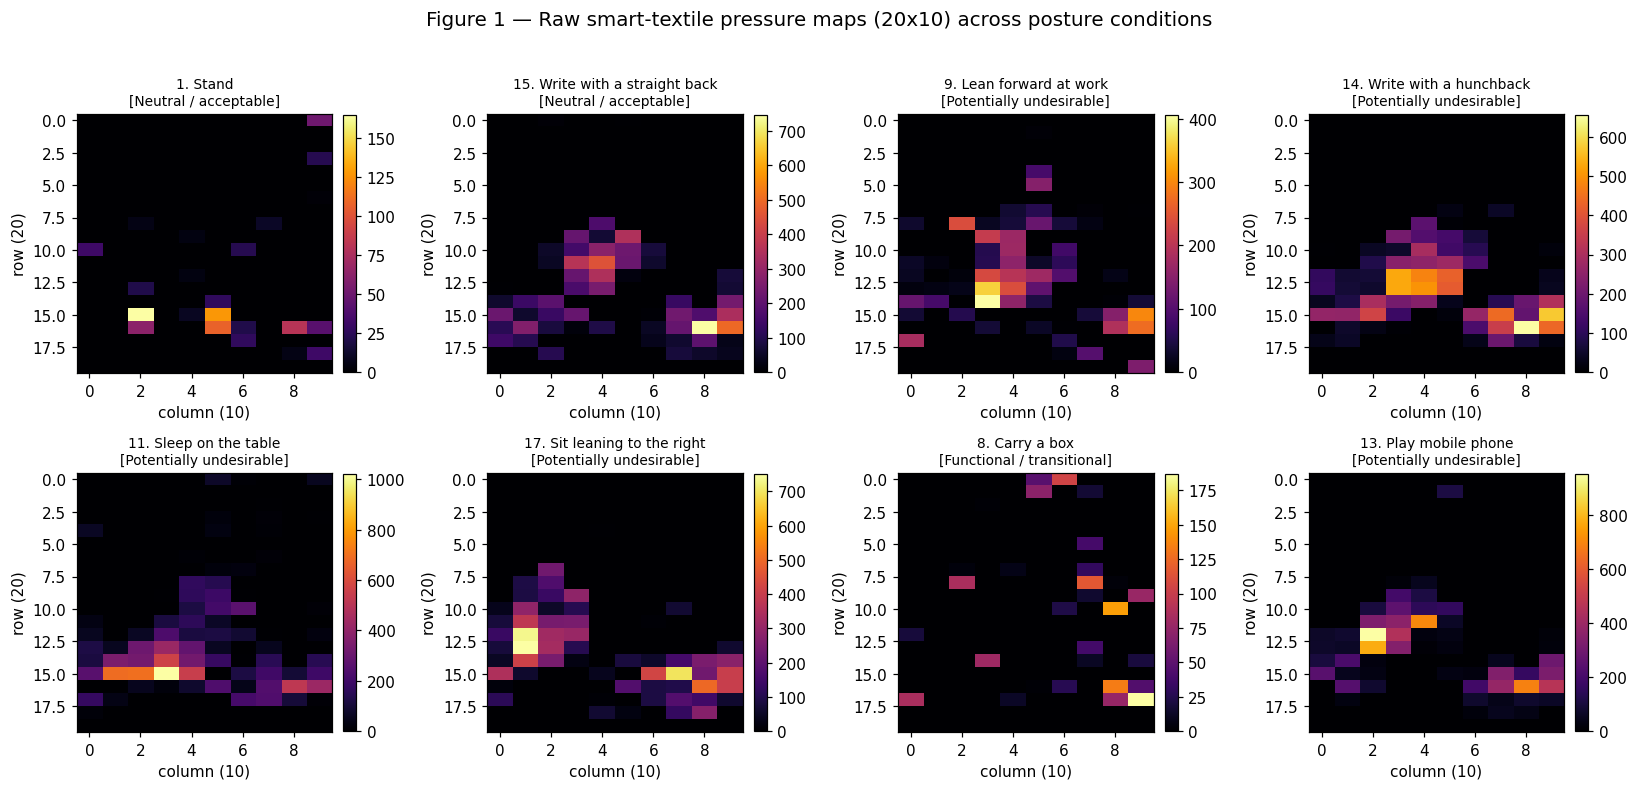

In [10]:
# Collect one representative frame per activity (middle frame of its first segment).
rep_frames = {}
for (sid, rid, dp, lp) in records:
    frames, lab, _ = load_round(dp, lp)
    for (pidx, s, e) in lab:
        if pidx in ACTIVITY_NAMES and pidx not in rep_frames:
            s = max(0, int(s)); e = min(len(frames) - 1, int(e))
            if e >= s:
                rep_frames[pidx] = frames[(s + e) // 2]
    if len(rep_frames) == len(ACTIVITY_NAMES):
        break

# Show 8 activities spanning the screening classes.
show = [1, 15, 9, 14, 11, 17, 8, 13]
show = [p for p in show if p in rep_frames][:8]
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, p in zip(axes.ravel(), show):
    im = ax.imshow(rep_frames[p], aspect="auto", cmap="inferno")
    ax.set_title(f"{p}. {ACTIVITY_NAMES[p]}\n[{SNAMES[SMAP[p]]}]", fontsize=9)
    ax.set_xlabel("column (10)"); ax.set_ylabel("row (20)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Figure 1 — Raw smart-textile pressure maps (20x10) across posture conditions",
             fontsize=13, y=1.02)
fig.tight_layout()
save_fig(fig, "figure1_pressure_maps")
plt.show()


## Section 7 — Feature engineering (interpretable pressure-distribution features)

We do not rely only on the 200 raw values. For **every frame** we compute interpretable
descriptors of the pressure distribution, grouped as: global magnitude, activation/area,
spatial centroid & spread, left/right & upper/lower asymmetry, quadrant ratios, and
pattern complexity (entropy, concentration). Optional **within-segment** temporal features
(change in total pressure, centroid displacement) are added because frame order is reliable
*inside* a labelled segment.


In [11]:
ROW_IDX = np.arange(GRID_ROWS)   # y-axis (20)
COL_IDX = np.arange(GRID_COLS)   # x-axis (10)

def compute_features_batch(F, active_thresh, high_thresh):
    "Vectorised features for a stack of frames F with shape (N, 20, 10)."
    N = F.shape[0]
    flat = F.reshape(N, -1)
    total = flat.sum(1)
    tsafe = np.where(total <= 0, 1.0, total)          # avoid divide-by-zero
    f = {}
    # 1) Global pressure
    f["mean_pressure"]   = flat.mean(1)
    f["max_pressure"]    = flat.max(1)
    f["min_pressure"]    = flat.min(1)
    f["std_pressure"]    = flat.std(1)
    f["total_pressure"]  = total
    f["median_pressure"] = np.median(flat, 1)
    f["p90_pressure"]    = np.percentile(flat, 90, axis=1)
    f["p95_pressure"]    = np.percentile(flat, 95, axis=1)
    f["range_pressure"]  = f["max_pressure"] - f["min_pressure"]
    # 2) Activation / area
    active = flat > active_thresh
    f["active_cells"]     = active.sum(1).astype(float)
    f["active_pct"]       = f["active_cells"] / flat.shape[1] * 100.0
    f["active_area_high"] = (flat > high_thresh).sum(1) / flat.shape[1] * 100.0
    # 3) Spatial distribution (centre of pressure & spread)
    rowsum = F.sum(2)   # (N,20) profile along y
    colsum = F.sum(1)   # (N,10) profile along x
    cop_y = (rowsum * ROW_IDX).sum(1) / tsafe
    cop_x = (colsum * COL_IDX).sum(1) / tsafe
    var_y = (rowsum * (ROW_IDX[None, :] - cop_y[:, None]) ** 2).sum(1) / tsafe
    var_x = (colsum * (COL_IDX[None, :] - cop_x[:, None]) ** 2).sum(1) / tsafe
    f["cop_x"], f["cop_y"] = cop_x, cop_y
    f["var_x"], f["var_y"] = var_x, var_y
    f["spread_x"] = np.sqrt(np.clip(var_x, 0, None))
    f["spread_y"] = np.sqrt(np.clip(var_y, 0, None))
    # 4) Asymmetry
    left  = F[:, :, 0:5].sum((1, 2)); right = F[:, :, 5:10].sum((1, 2))
    upper = F[:, 0:10, :].sum((1, 2)); lower = F[:, 10:20, :].sum((1, 2))
    f["lr_diff"] = (right - left) / tsafe
    f["ud_diff"] = (lower - upper) / tsafe
    tl = F[:, 0:10, 0:5].sum((1, 2)); tr = F[:, 0:10, 5:10].sum((1, 2))
    bl = F[:, 10:20, 0:5].sum((1, 2)); br = F[:, 10:20, 5:10].sum((1, 2))
    f["quad_tl_ratio"] = tl / tsafe; f["quad_tr_ratio"] = tr / tsafe
    f["quad_bl_ratio"] = bl / tsafe; f["quad_br_ratio"] = br / tsafe
    # 5) Pattern complexity
    p = flat / tsafe[:, None]
    f["entropy"] = -(np.where(p > 0, p * np.log(p), 0.0)).sum(1)
    f["concentration_top10"] = np.sort(flat, 1)[:, -10:].sum(1) / tsafe
    f["max_to_total"] = f["max_pressure"] / tsafe
    return f

FEATURE_GROUPS = {
    "global": ["mean_pressure","max_pressure","min_pressure","std_pressure","total_pressure",
               "median_pressure","p90_pressure","p95_pressure","range_pressure"],
    "activation": ["active_cells","active_pct","active_area_high"],
    "spatial": ["cop_x","cop_y","var_x","var_y","spread_x","spread_y"],
    "asymmetry": ["lr_diff","ud_diff","quad_tl_ratio","quad_tr_ratio","quad_bl_ratio","quad_br_ratio"],
    "complexity": ["entropy","concentration_top10","max_to_total"],
}
if CONFIG["include_temporal"]:
    FEATURE_GROUPS["temporal"] = ["delta_total","centroid_disp"]
print("Feature groups:")
for g, names in FEATURE_GROUPS.items():
    print(f"  {g:11s}: {names}")


Feature groups:
  global     : ['mean_pressure', 'max_pressure', 'min_pressure', 'std_pressure', 'total_pressure', 'median_pressure', 'p90_pressure', 'p95_pressure', 'range_pressure']
  activation : ['active_cells', 'active_pct', 'active_area_high']
  spatial    : ['cop_x', 'cop_y', 'var_x', 'var_y', 'spread_x', 'spread_y']
  asymmetry  : ['lr_diff', 'ud_diff', 'quad_tl_ratio', 'quad_tr_ratio', 'quad_bl_ratio', 'quad_br_ratio']
  complexity : ['entropy', 'concentration_top10', 'max_to_total']
  temporal   : ['delta_total', 'centroid_disp']


In [12]:
# ----------------- Build the frame-level feature table ------------------
stride = CONFIG["frame_stride"]
cap    = CONFIG["max_frames_per_segment"]
at, ht = CONFIG["active_thresh"], CONFIG["high_thresh"]

chunks = []
for (sid, rid, dp, lp) in records:
    frames, lab, _ = load_round(dp, lp)
    nfr = len(frames)
    for (pidx, s, e) in lab:
        if pidx not in ACTIVITY_NAMES:
            continue
        s = max(0, int(s)); e = min(nfr - 1, int(e))
        if e < s:
            continue
        idx = np.arange(s, e + 1, stride)
        if cap:
            idx = idx[:cap]
        if len(idx) == 0:
            continue
        seg = frames[idx]
        feats = compute_features_batch(seg, at, ht)
        if CONFIG["include_temporal"]:
            tot, cx, cy = feats["total_pressure"], feats["cop_x"], feats["cop_y"]
            feats["delta_total"]   = np.abs(np.diff(tot, prepend=tot[:1]))
            feats["centroid_disp"] = np.sqrt(np.diff(cx, prepend=cx[:1]) ** 2 +
                                             np.diff(cy, prepend=cy[:1]) ** 2)
        df = pd.DataFrame(feats)
        df["subject_id"]     = sid
        df["round_id"]       = rid
        df["activity_idx"]   = pidx
        df["activity_name"]  = ACTIVITY_NAMES[pidx]
        df["screening_class"] = SMAP[pidx]
        df["screening_name"]  = SNAMES[SMAP[pidx]]
        chunks.append(df)

feature_df = pd.concat(chunks, ignore_index=True)
META = ["subject_id","round_id","activity_idx","activity_name","screening_class","screening_name"]
FEATURES = [c for c in feature_df.columns if c not in META]

print("Feature table shape (frames, columns):", feature_df.shape)
print("Number of engineered features        :", len(FEATURES))
print("\nClass distribution (frames):")
print(feature_df["screening_name"].value_counts().to_string())
print("\nFrames per subject:")
print(feature_df["subject_id"].value_counts().sort_index().to_string())

feature_df.to_csv(os.path.join(DIRS["data"], "feature_table.csv"), index=False)
with open(os.path.join(DIRS["results"], "feature_names.json"), "w") as fp:
    json.dump(FEATURES, fp, indent=2)
print("\nSaved feature_table.csv and feature_names.json")


Feature table shape (frames, columns): (84095, 35)
Number of engineered features        : 29

Class distribution (frames):
screening_name
Potentially undesirable      40373
Functional / transitional    24961
Neutral / acceptable         18761

Frames per subject:
subject_id
1     5082
2     4489
3     5419
4     5683
5     4954
6     6053
7     6280
8     6966
9     7263
10    6752
11    5946
12    5754
13    8911
14    4543

Saved feature_table.csv and feature_names.json


## Section 7b — Exploratory feature comparison (Figure 2)

We compare a few interpretable features across the screening categories to check they carry
class-relevant signal.


saved: /kaggle/working/smart_textile_postural_risk_output/figures/figure2_feature_comparison.png


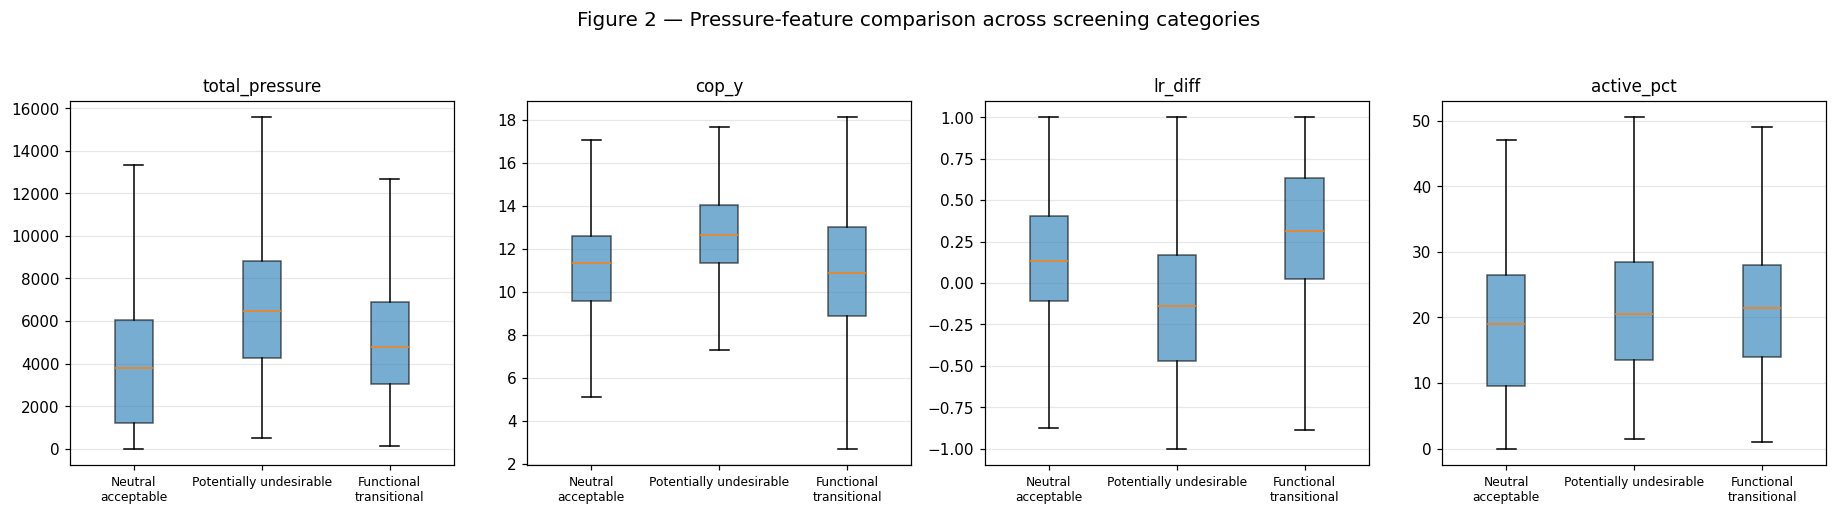

In [13]:
compare_feats = ["total_pressure", "cop_y", "lr_diff", "active_pct"]
order = [SNAMES[k] for k in sorted(SNAMES)]
fig, axes = plt.subplots(1, len(compare_feats), figsize=(4.2 * len(compare_feats), 4.5))
for ax, feat in zip(np.atleast_1d(axes), compare_feats):
    data = [feature_df.loc[feature_df["screening_name"] == g, feat].values for g in order]
    bp = ax.boxplot(data, showfliers=False, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_alpha(0.6)
    ax.set_title(feat, fontsize=11)
    ax.set_xticklabels([g.replace(" / ", "\n") for g in order], fontsize=8, rotation=0)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Figure 2 — Pressure-feature comparison across screening categories",
             fontsize=13, y=1.03)
fig.tight_layout()
save_fig(fig, "figure2_feature_comparison")
plt.show()


## Section 9 — Subject-wise train / validation / test split

**Critical anti-leakage rule.** Consecutive frames come from the same person and session, so a
random frame-level split would leak. We split **by subject**: whole subjects go to exactly one
of train / validation / test. Final evaluation uses subjects **never seen** during training or
tuning. We also expose `GroupKFold(subject_id)` for the hyper-parameter search.


In [14]:
from sklearn.utils.class_weight import compute_sample_weight

all_subjects = np.array(sorted(feature_df["subject_id"].unique()))
rng = np.random.RandomState(SEED)
perm = rng.permutation(all_subjects)
n = len(perm)
n_test = max(1, round(CONFIG["test_ratio"] * n))
n_val  = max(1, round(CONFIG["val_ratio"]  * n))
test_subjects  = sorted(perm[:n_test].tolist())
val_subjects   = sorted(perm[n_test:n_test + n_val].tolist())
train_subjects = sorted(perm[n_test + n_val:].tolist())

assert not (set(train_subjects) & set(val_subjects))
assert not (set(train_subjects) & set(test_subjects))
assert not (set(val_subjects)  & set(test_subjects))

def subset(df, subs):
    return df[df["subject_id"].isin(subs)].reset_index(drop=True)

train_df, val_df, test_df = subset(feature_df, train_subjects), \
                            subset(feature_df, val_subjects), \
                            subset(feature_df, test_subjects)

Xtr, ytr, gtr = train_df[FEATURES].values, train_df["screening_class"].values, train_df["subject_id"].values
Xval, yval    = val_df[FEATURES].values,   val_df["screening_class"].values
Xte, yte      = test_df[FEATURES].values,  test_df["screening_class"].values
w_tr = compute_sample_weight("balanced", ytr)
CLASSES = sorted(feature_df["screening_class"].unique())
CLASS_LABELS = [SNAMES[c] for c in CLASSES]

with open(os.path.join(DIRS["results"], "split_subjects.json"), "w") as fp:
    json.dump({"train": train_subjects, "val": val_subjects, "test": test_subjects}, fp, indent=2)

print("Subject-wise split")
print(f"  train subjects ({len(train_subjects)}): {train_subjects}")
print(f"  val   subjects ({len(val_subjects)}): {val_subjects}")
print(f"  test  subjects ({len(test_subjects)}): {test_subjects}")


Subject-wise split
  train subjects (10): [2, 3, 4, 5, 6, 7, 8, 9, 11, 14]
  val   subjects (2): [1, 13]
  test  subjects (2): [10, 12]


In [15]:
# --------------- Pre-training summary print (sanity) --------------------
print("=" * 64)
print("PRE-TRAINING SUMMARY")
print("=" * 64)
print(f"Feature-table shape : {feature_df.shape}")
print(f"Screening scheme    : {CONFIG['screening_scheme']}  -> classes {CLASSES} = {CLASS_LABELS}")
print(f"# subjects          : {len(all_subjects)}")
print(f"# trials (sub-round): {len(records)}")
print(f"# engineered feats  : {len(FEATURES)}")
print("\nClass distribution per split (frames):")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = d["screening_class"].value_counts().sort_index().to_dict()
    print(f"  {name:5s}: " + ", ".join(f"{SNAMES[k]}={counts.get(k,0)}" for k in CLASSES))
print(f"\nFrames  train/val/test : {len(train_df)}/{len(val_df)}/{len(test_df)}")


PRE-TRAINING SUMMARY
Feature-table shape : (84095, 35)
Screening scheme    : three_class  -> classes [np.int64(0), np.int64(1), np.int64(2)] = ['Neutral / acceptable', 'Potentially undesirable', 'Functional / transitional']
# subjects          : 14
# trials (sub-round): 140
# engineered feats  : 29

Class distribution per split (frames):
  train: Neutral / acceptable=13037, Potentially undesirable=27534, Functional / transitional=17025
  val  : Neutral / acceptable=2944, Potentially undesirable=6671, Functional / transitional=4378
  test : Neutral / acceptable=2780, Potentially undesirable=6168, Functional / transitional=3558

Frames  train/val/test : 57596/13993/12506


## Section 10 — Baseline models

To show the main model is meaningful, we compare against two baselines only:
**Logistic Regression** (with feature scaling inside the pipeline, so scaling is fit on
training data only) and **Random Forest**. Both use balanced class weights.


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])
logreg.fit(Xtr, ytr)

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                            random_state=SEED, n_jobs=-1)
rf.fit(Xtr, ytr)
print("Baselines trained: Logistic Regression, Random Forest.")


Baselines trained: Logistic Regression, Random Forest.


## Section 11 — XGBoost (primary model)

XGBoost is our main model: strong on tabular features, lightweight, and pairs naturally with
SHAP. We run a **compact** randomized search validated with `GroupKFold(subject_id)` on the
training set only, then refit the best configuration with **early stopping** on the held-out
validation subjects.


In [17]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

n_splits = min(5, len(train_subjects))
gkf = GroupKFold(n_splits=n_splits)
eval_metric = "logloss" if len(CLASSES) == 2 else "mlogloss"

param_dist = {
    "n_estimators":      [100, 200, 300, 400, 500],
    "max_depth":         [2, 3, 4, 5, 6, 8],
    "learning_rate":     [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample":         [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":  [0.7, 0.8, 0.9, 1.0],
    "min_child_weight":  [1, 3, 5, 7],
    "reg_alpha":         [0.0, 0.1, 0.5],
    "reg_lambda":        [1.0, 2.0, 5.0],
}

base_xgb = XGBClassifier(tree_method="hist", eval_metric=eval_metric,
                         random_state=SEED, n_jobs=-1)
search = RandomizedSearchCV(
    base_xgb, param_dist, n_iter=20, scoring="f1_macro",
    cv=gkf, random_state=SEED, n_jobs=-1, verbose=1, refit=False,
)
search.fit(Xtr, ytr, groups=gtr, sample_weight=w_tr)
best_params = search.best_params_
print("\nBest params (grouped CV, macro-F1 = %.4f):" % search.best_score_)
print(json.dumps(best_params, indent=2))


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params (grouped CV, macro-F1 = 0.7674):
{
  "subsample": 0.8,
  "reg_lambda": 1.0,
  "reg_alpha": 0.0,
  "n_estimators": 500,
  "min_child_weight": 5,
  "max_depth": 4,
  "learning_rate": 0.03,
  "colsample_bytree": 0.7
}


In [18]:
# ------------- Final XGBoost fit with early stopping on val -------------
def fit_final_xgb(params):
    try:
        m = XGBClassifier(**params, tree_method="hist", eval_metric=eval_metric,
                          early_stopping_rounds=30, random_state=SEED, n_jobs=-1)
        m.fit(Xtr, ytr, sample_weight=w_tr, eval_set=[(Xval, yval)], verbose=False)
        print("Early stopping used. Best iteration:", getattr(m, "best_iteration", "n/a"))
        return m
    except TypeError:
        m = XGBClassifier(**params, tree_method="hist", eval_metric=eval_metric,
                          random_state=SEED, n_jobs=-1)
        m.fit(Xtr, ytr, sample_weight=w_tr)
        print("Early stopping unsupported in this xgboost version; fitted without it.")
        return m

xgb_model = fit_final_xgb(best_params)
xgb_model.save_model(os.path.join(DIRS["models"], "xgboost_model.json"))
print("Final XGBoost trained and saved.")


Early stopping used. Best iteration: 311
Final XGBoost trained and saved.


## Section 12 — Evaluation on unseen test subjects

We report **more than accuracy**: balanced accuracy, macro precision/recall/F1, ROC-AUC
(binary) or macro one-vs-rest AUC (multiclass), a confusion matrix, and per-class recall — with
emphasis on balanced accuracy and macro-F1 because the classes are imbalanced.


In [19]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

def evaluate(name, model, X, y):
    yp = model.predict(X)
    try:
        proba = model.predict_proba(X)
    except Exception:
        proba = None
    auc = np.nan
    if proba is not None:
        try:
            if len(CLASSES) == 2:
                auc = roc_auc_score(y, proba[:, 1])
            else:
                auc = roc_auc_score(y, proba, multi_class="ovr", average="macro")
        except Exception:
            pass
    row = {"model": name,
           "accuracy": accuracy_score(y, yp),
           "balanced_accuracy": balanced_accuracy_score(y, yp),
           "precision_macro": precision_score(y, yp, average="macro", zero_division=0),
           "recall_macro": recall_score(y, yp, average="macro", zero_division=0),
           "f1_macro": f1_score(y, yp, average="macro", zero_division=0),
           "roc_auc": auc}
    return row, yp, proba

results = []
for nm, mdl in [("Logistic Regression", logreg), ("Random Forest", rf), ("XGBoost", xgb_model)]:
    row, yp, proba = evaluate(nm, mdl, Xte, yte)
    results.append(row)

metrics_df = pd.DataFrame(results).set_index("model").round(4)
metrics_df.to_csv(os.path.join(DIRS["results"], "model_comparison_metrics.csv"))
print("Test-set metrics (unseen subjects):\n")
print(metrics_df.to_string())

# Detailed per-class report for the final XGBoost model.
xgb_pred = xgb_model.predict(Xte)
print("\nXGBoost per-class report (test):")
print(classification_report(yte, xgb_pred, target_names=CLASS_LABELS, zero_division=0))
report_dict = classification_report(yte, xgb_pred, target_names=CLASS_LABELS,
                                    zero_division=0, output_dict=True)
pd.DataFrame(report_dict).T.round(4).to_csv(
    os.path.join(DIRS["results"], "xgboost_classification_report.csv"))

# Save test predictions with subject IDs.
pred_df = test_df[["subject_id", "round_id", "activity_idx", "activity_name",
                   "screening_class", "screening_name"]].copy()
pred_df["predicted_class"] = xgb_pred
pred_df["predicted_name"] = [SNAMES[c] for c in xgb_pred]
pred_df.to_csv(os.path.join(DIRS["results"], "test_predictions.csv"), index=False)
print("\nSaved model_comparison_metrics.csv, classification report, and test_predictions.csv")


Test-set metrics (unseen subjects):

                     accuracy  balanced_accuracy  precision_macro  recall_macro  f1_macro  roc_auc
model                                                                                             
Logistic Regression    0.7302             0.6684           0.7099        0.6684    0.6812   0.8726
Random Forest          0.7930             0.7369           0.8176        0.7369    0.7619   0.9328
XGBoost                0.8183             0.7876           0.8228        0.7876    0.8007   0.9416

XGBoost per-class report (test):
                           precision    recall  f1-score   support

     Neutral / acceptable       0.77      0.73      0.75      2780
  Potentially undesirable       0.81      0.92      0.86      6168
Functional / transitional       0.89      0.72      0.79      3558

                 accuracy                           0.82     12506
                macro avg       0.82      0.79      0.80     12506
             weighted avg     

saved: /kaggle/working/smart_textile_postural_risk_output/figures/figure3_model_comparison.png


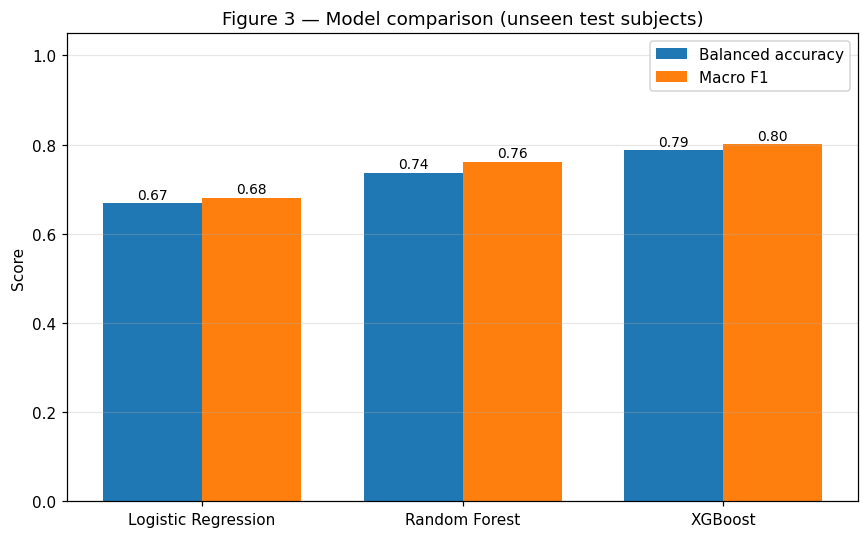

In [20]:
# --------------------- Figure 3: model comparison ----------------------
fig, ax = plt.subplots(figsize=(8, 5))
models = metrics_df.index.tolist()
x = np.arange(len(models)); width = 0.38
ax.bar(x - width/2, metrics_df["balanced_accuracy"], width, label="Balanced accuracy")
ax.bar(x + width/2, metrics_df["f1_macro"], width, label="Macro F1")
for i, m in enumerate(models):
    ax.text(i - width/2, metrics_df["balanced_accuracy"][m] + 0.01,
            f"{metrics_df['balanced_accuracy'][m]:.2f}", ha="center", fontsize=9)
    ax.text(i + width/2, metrics_df["f1_macro"][m] + 0.01,
            f"{metrics_df['f1_macro'][m]:.2f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Figure 3 — Model comparison (unseen test subjects)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_fig(fig, "figure3_model_comparison")
plt.show()


saved: /kaggle/working/smart_textile_postural_risk_output/figures/figure4_confusion_matrix.png


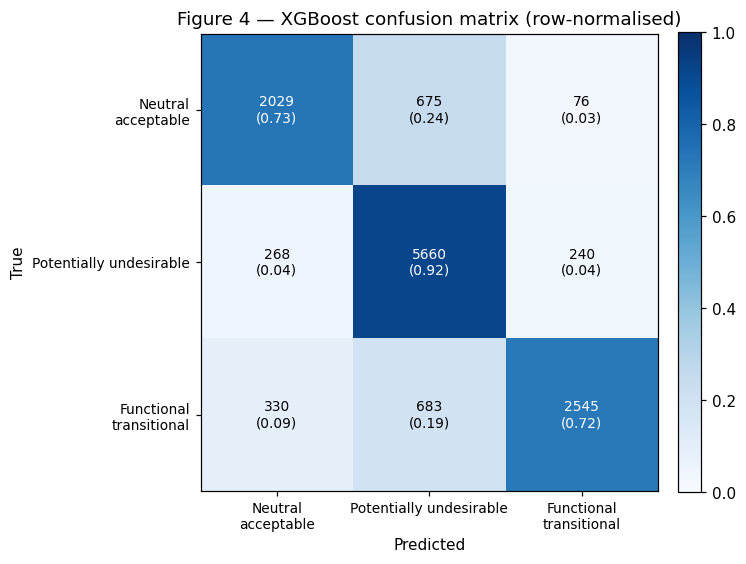

In [21]:
# --------------------- Figure 4: confusion matrix ----------------------
cm = confusion_matrix(yte, xgb_pred, labels=CLASSES)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels([l.replace(" / ", "\n") for l in CLASS_LABELS], fontsize=9)
ax.set_yticklabels([l.replace(" / ", "\n") for l in CLASS_LABELS], fontsize=9)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]:.2f})", ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=9)
ax.set_title("Figure 4 — XGBoost confusion matrix (row-normalised)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
save_fig(fig, "figure4_confusion_matrix")
plt.show()


## Section 13 — Explainability with SHAP

We explain the final XGBoost model with SHAP: a **global** importance ranking (Figure 5), a
**beeswarm** summary, a **class-specific** view for the *potentially undesirable* class, and
**individual** prediction explanations (Figure 6). Interpretations are read off the actual SHAP
output — we do not force them by hand.


In [22]:
import shap

# Sample test rows for speed.
n_s = min(CONFIG["shap_sample"], len(test_df))
samp = test_df.sample(n_s, random_state=SEED).reset_index(drop=True)
Xs = samp[FEATURES].values

explainer = shap.TreeExplainer(xgb_model)
sv = explainer.shap_values(Xs)

# Normalise SHAP output to array (N, F, K) regardless of version/scheme.
def to_3d(sv, n, fdim, k):
    if isinstance(sv, list):                       # list of (N,F) per class
        return np.stack(sv, axis=-1)
    sv = np.asarray(sv)
    if sv.ndim == 2:                               # (N,F) -> binary, class-1 margin
        return np.stack([-sv, sv], axis=-1)
    if sv.ndim == 3 and sv.shape[-1] == k:         # (N,F,K)
        return sv
    if sv.ndim == 3 and sv.shape[0] == k:          # (K,N,F)
        return np.transpose(sv, (1, 2, 0))
    return sv

sv3 = to_3d(sv, len(Xs), len(FEATURES), len(CLASSES))
mean_abs = np.abs(sv3).mean(axis=0)                # (F, K)
global_imp = mean_abs.mean(axis=1)                 # average over classes
order_g = np.argsort(global_imp)[::-1]

# Data-driven interpretation for the "potentially undesirable" class (label 1).
und_idx = CLASSES.index(1) if 1 in CLASSES else (len(CLASSES) - 1)
und_shap = sv3[:, :, und_idx]                      # (N, F)
imp_rows = []
for fj in range(len(FEATURES)):
    corr = np.corrcoef(Xs[:, fj], und_shap[:, fj])[0, 1]
    direction = ("higher values push toward 'potentially undesirable'"
                 if np.nan_to_num(corr) >= 0 else
                 "higher values push away from 'potentially undesirable'")
    imp_rows.append({"feature": FEATURES[fj],
                     "mean_abs_shap_global": float(global_imp[fj]),
                     "mean_abs_shap_undesirable": float(mean_abs[fj, und_idx]),
                     "interpretation": direction})
shap_imp_df = (pd.DataFrame(imp_rows)
               .sort_values("mean_abs_shap_global", ascending=False)
               .reset_index(drop=True))
shap_imp_df.round(5).to_csv(os.path.join(DIRS["results"], "shap_feature_importance.csv"),
                            index=False)
print("Top 12 features by global mean|SHAP|:\n")
print(shap_imp_df.head(12).to_string(index=False))


Top 12 features by global mean|SHAP|:

            feature  mean_abs_shap_global  mean_abs_shap_undesirable                                         interpretation
              cop_x              0.388266                   0.198716 higher values push away from 'potentially undesirable'
              var_x              0.293003                   0.445408 higher values push away from 'potentially undesirable'
       std_pressure              0.280307                   0.365959    higher values push toward 'potentially undesirable'
              cop_y              0.278556                   0.240051    higher values push toward 'potentially undesirable'
      mean_pressure              0.157618                   0.121681    higher values push toward 'potentially undesirable'
              var_y              0.131692                   0.031614 higher values push away from 'potentially undesirable'
      quad_bl_ratio              0.121696                   0.242946    higher values push to

saved: /kaggle/working/smart_textile_postural_risk_output/figures/figure5_shap_global_importance.png


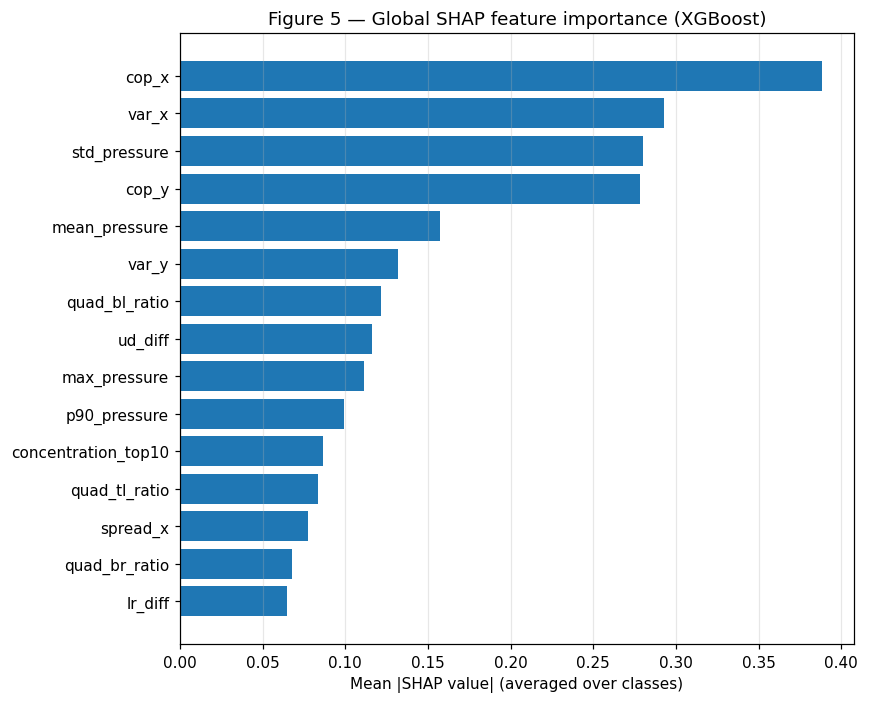

saved: /kaggle/working/smart_textile_postural_risk_output/figures/figure5b_shap_beeswarm_undesirable.png


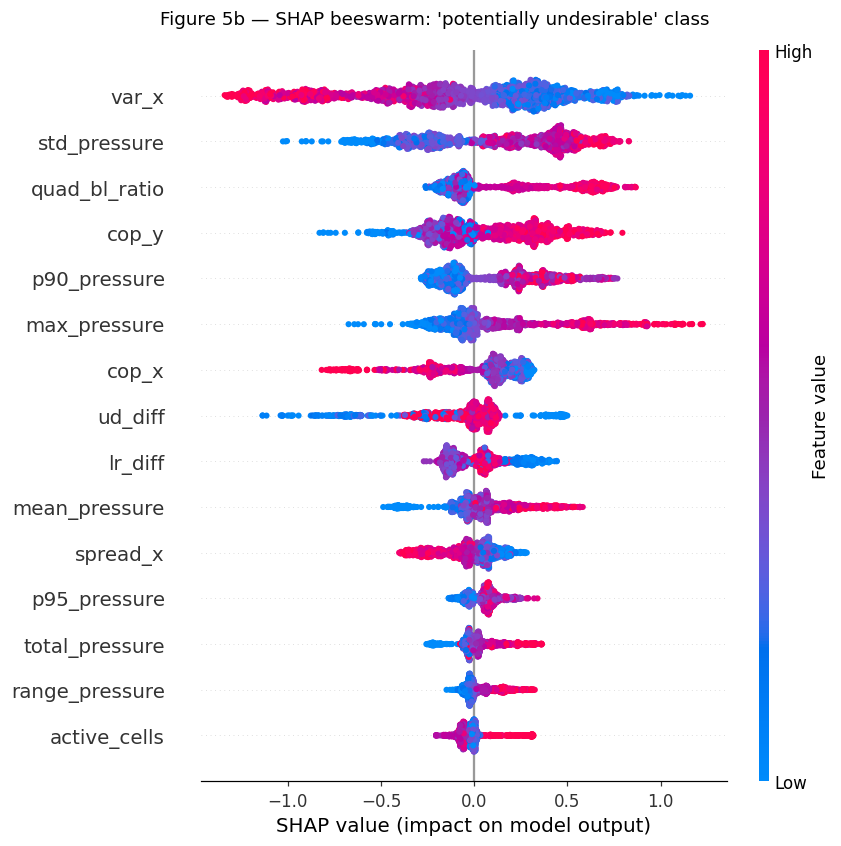

In [23]:
# --------------------- Figure 5: global SHAP importance ----------------
top = shap_imp_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(top["feature"], top["mean_abs_shap_global"])
ax.set_xlabel("Mean |SHAP value| (averaged over classes)")
ax.set_title("Figure 5 — Global SHAP feature importance (XGBoost)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
save_fig(fig, "figure5_shap_global_importance")
plt.show()

# Beeswarm for the 'potentially undesirable' class (best-effort, version-robust).
try:
    plt.figure()
    shap.summary_plot(und_shap, Xs, feature_names=FEATURES, show=False, max_display=15)
    fig_bee = plt.gcf()
    fig_bee.suptitle("Figure 5b — SHAP beeswarm: 'potentially undesirable' class", y=1.02)
    save_fig(fig_bee, "figure5b_shap_beeswarm_undesirable")
    plt.show()
except Exception as e:
    print("Beeswarm skipped:", e)


saved: /kaggle/working/smart_textile_postural_risk_output/figures/figure6_shap_individual_undesirable.png


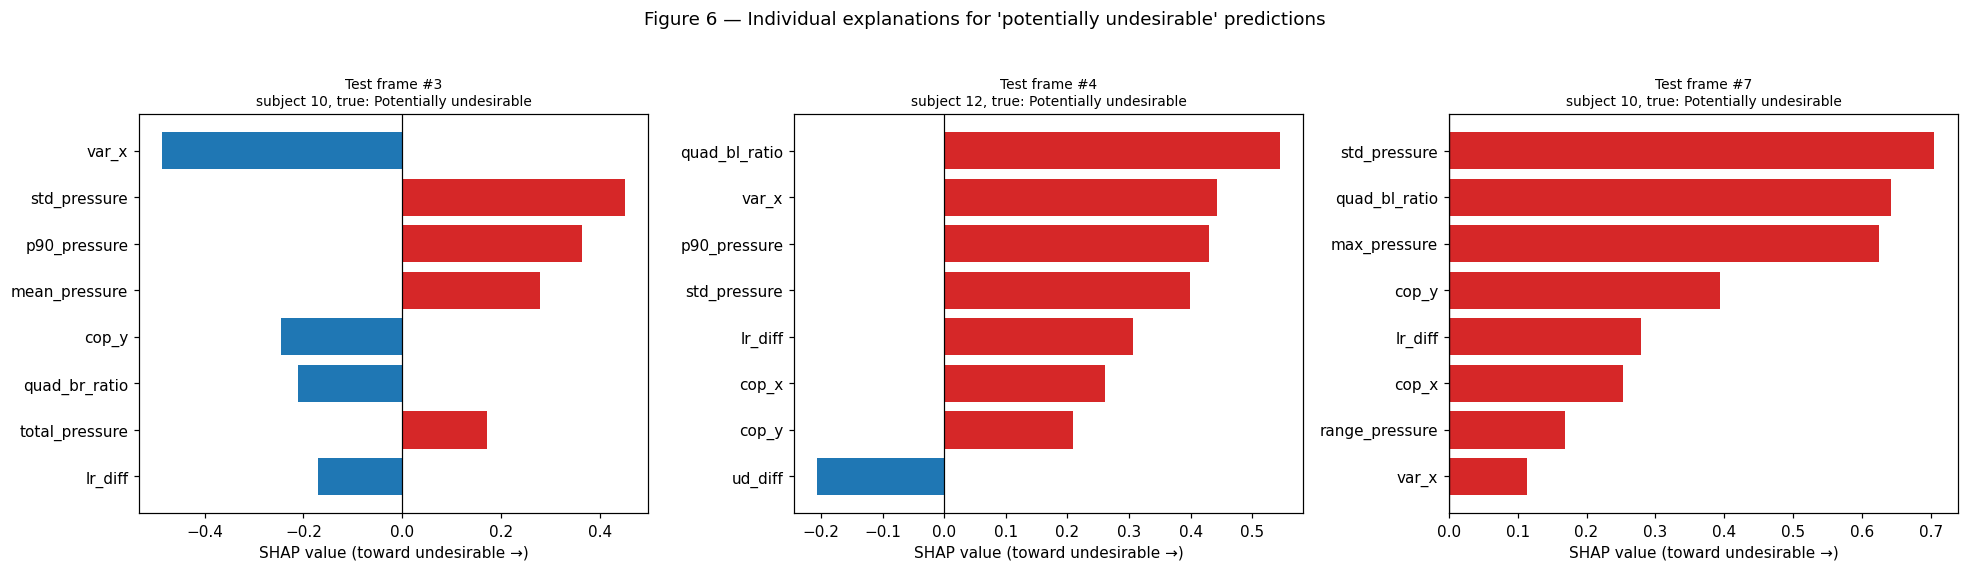

In [24]:
# ---------- Figure 6: individual explanations (undesirable) -------------
pred_s = xgb_model.predict(Xs)
cand = np.where(pred_s == 1)[0] if 1 in CLASSES else np.arange(len(Xs))
cand = cand[:3] if len(cand) else np.arange(min(3, len(Xs)))

fig, axes = plt.subplots(1, len(cand), figsize=(6 * len(cand), 5))
for ax, i in zip(np.atleast_1d(axes), cand):
    contrib = und_shap[i]
    order_i = np.argsort(np.abs(contrib))[::-1][:8][::-1]
    vals = contrib[order_i]
    ax.barh([FEATURES[k] for k in order_i], vals,
            color=["#d62728" if v > 0 else "#1f77b4" for v in vals])
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"Test frame #{i}\nsubject {int(samp.loc[i,'subject_id'])}, "
                 f"true: {samp.loc[i,'screening_name']}", fontsize=9)
    ax.set_xlabel("SHAP value (toward undesirable →)")
fig.suptitle("Figure 6 — Individual explanations for 'potentially undesirable' predictions",
             y=1.03, fontsize=12)
fig.tight_layout()
save_fig(fig, "figure6_shap_individual_undesirable")
plt.show()


## Section 14 — Poster figures (pipeline & side-by-side)

saved: /kaggle/working/smart_textile_postural_risk_output/figures/figure7_pipeline.png


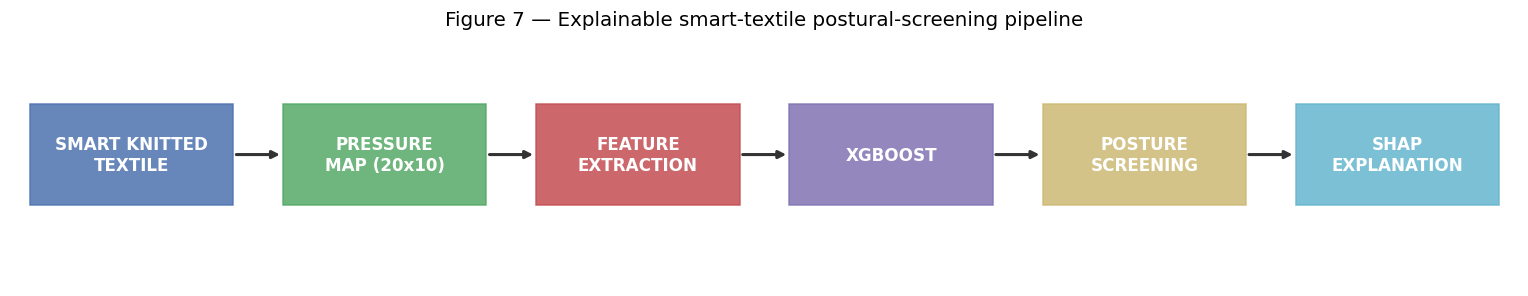

In [25]:
# --------------------- Figure 7: conceptual pipeline -------------------
fig, ax = plt.subplots(figsize=(14, 2.8))
ax.axis("off")
steps = ["SMART KNITTED\nTEXTILE", "PRESSURE\nMAP (20x10)", "FEATURE\nEXTRACTION",
         "XGBOOST", "POSTURE\nSCREENING", "SHAP\nEXPLANATION"]
colors = ["#4C72B0","#55A868","#C44E52","#8172B3","#CCB974","#64B5CD"]
n = len(steps); box_w, gap = 0.135, 0.033
x0 = (1 - (n * box_w + (n - 1) * gap)) / 2
for i, (s, c) in enumerate(zip(steps, colors)):
    x = x0 + i * (box_w + gap)
    ax.add_patch(plt.Rectangle((x, 0.32), box_w, 0.4, color=c, alpha=0.85))
    ax.text(x + box_w/2, 0.52, s, ha="center", va="center", color="white",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w + gap, 0.52), xytext=(x + box_w, 0.52),
                    arrowprops=dict(arrowstyle="-|>", lw=2, color="#333"))
ax.set_title("Figure 7 — Explainable smart-textile postural-screening pipeline",
             fontsize=13)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig.tight_layout()
save_fig(fig, "figure7_pipeline")
plt.show()


saved: /kaggle/working/smart_textile_postural_risk_output/figures/figure8_side_by_side.png


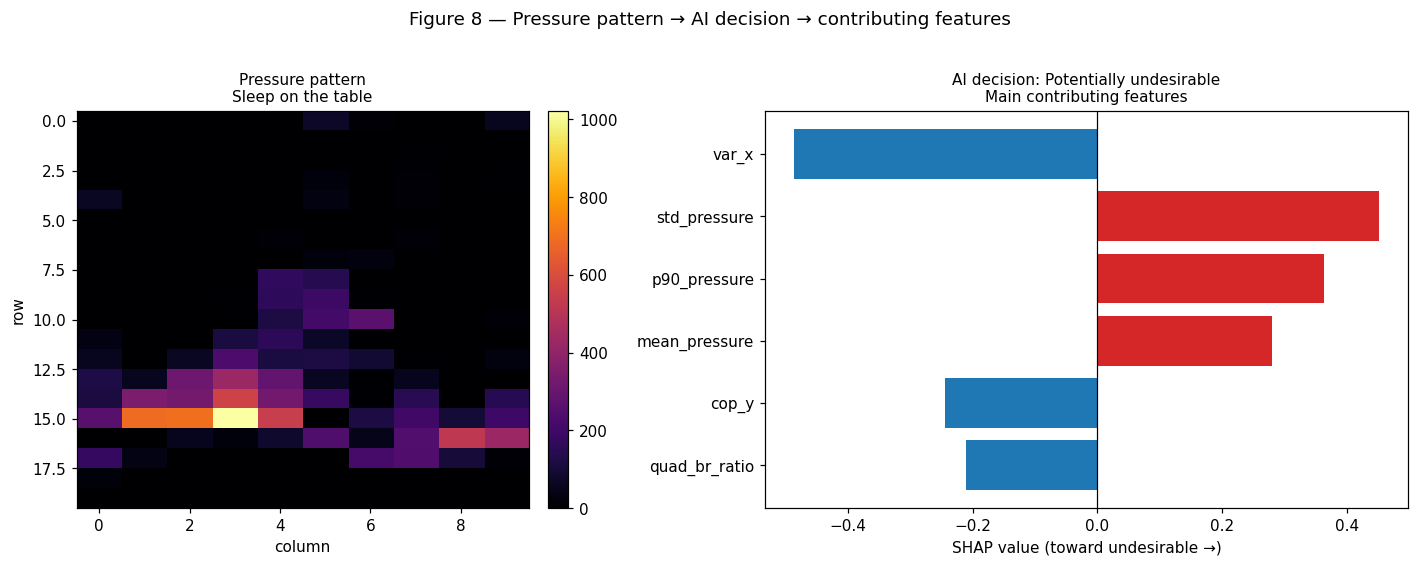

In [26]:
# ------- Figure 8: pressure map -> AI decision -> top features ----------
i = int(cand[0]) if len(cand) else 0
frame_idx_in_samp = samp.index[i]
# Reconstruct a representative frame for this example's activity for display.
disp_activity = int(samp.loc[i, "activity_idx"])
disp_frame = rep_frames.get(disp_activity, list(rep_frames.values())[0])
contrib = und_shap[i]
order_i = np.argsort(np.abs(contrib))[::-1][:6][::-1]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5),
                             gridspec_kw={"width_ratios": [1, 1.3]})
im = a1.imshow(disp_frame, cmap="inferno", aspect="auto")
a1.set_title(f"Pressure pattern\n{ACTIVITY_NAMES[disp_activity]}", fontsize=10)
a1.set_xlabel("column"); a1.set_ylabel("row")
fig.colorbar(im, ax=a1, fraction=0.046, pad=0.04)
vals = contrib[order_i]
a2.barh([FEATURES[k] for k in order_i], vals,
        color=["#d62728" if v > 0 else "#1f77b4" for v in vals])
a2.axvline(0, color="k", lw=0.8)
pred_name = SNAMES[int(xgb_model.predict(Xs[i:i+1])[0])]
a2.set_title(f"AI decision: {pred_name}\nMain contributing features", fontsize=10)
a2.set_xlabel("SHAP value (toward undesirable →)")
fig.suptitle("Figure 8 — Pressure pattern → AI decision → contributing features",
             y=1.02, fontsize=12)
fig.tight_layout()
save_fig(fig, "figure8_side_by_side")
plt.show()


## Section 15 — Final results export & quality control

We save every artefact and run automatic **quality-control checks**: no subject leakage,
preprocessing fit only on training data, test subjects untouched during tuning, class mapping
documented, no injury labels, and SHAP tied to the final model.


In [27]:
# ------------------------- Results tables -------------------------------
print("FINAL RESULTS TABLE (test subjects)\n")
print(metrics_df.to_string())
print("\nFEATURE-IMPORTANCE TABLE (top 10 by SHAP)\n")
print(shap_imp_df.head(10)[["feature","mean_abs_shap_global","interpretation"]].to_string(index=False))

# ------------------------- Quality control ------------------------------
checks = {}
checks["no_train_test_subject_overlap"] = len(set(train_subjects) & set(test_subjects)) == 0
checks["no_train_val_subject_overlap"]  = len(set(train_subjects) & set(val_subjects)) == 0
checks["no_val_test_subject_overlap"]   = len(set(val_subjects) & set(test_subjects)) == 0
checks["scaler_fit_on_train_only"]      = isinstance(logreg.named_steps["scaler"], StandardScaler)
checks["class_mapping_documented"]      = os.path.exists(os.path.join(DIRS["results"], "class_mapping.csv"))
checks["no_injury_labels"]              = all("injur" not in v.lower() for v in SNAMES.values())
checks["shap_matches_final_model"]      = (explainer.model is not None)
checks["test_evaluated_on_unseen"]      = set(test_df["subject_id"]).isdisjoint(set(train_subjects) | set(val_subjects))

print("\nQUALITY-CONTROL CHECKS")
for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
assert all(checks.values()), "One or more QC checks failed."


FINAL RESULTS TABLE (test subjects)

                     accuracy  balanced_accuracy  precision_macro  recall_macro  f1_macro  roc_auc
model                                                                                             
Logistic Regression    0.7302             0.6684           0.7099        0.6684    0.6812   0.8726
Random Forest          0.7930             0.7369           0.8176        0.7369    0.7619   0.9328
XGBoost                0.8183             0.7876           0.8228        0.7876    0.8007   0.9416

FEATURE-IMPORTANCE TABLE (top 10 by SHAP)

      feature  mean_abs_shap_global                                         interpretation
        cop_x              0.388266 higher values push away from 'potentially undesirable'
        var_x              0.293003 higher values push away from 'potentially undesirable'
 std_pressure              0.280307    higher values push toward 'potentially undesirable'
        cop_y              0.278556    higher values push to

In [28]:
# ------------------------- Save everything ------------------------------
with open(os.path.join(DIRS["models"], "feature_names.json"), "w") as fp:
    json.dump(FEATURES, fp, indent=2)
with open(os.path.join(DIRS["results"], "run_config.json"), "w") as fp:
    json.dump({k: (v if not isinstance(v, (np.floating,)) else float(v))
               for k, v in CONFIG.items()}, fp, indent=2)

shap_tab = shap_imp_df.head(10)[["feature","mean_abs_shap_global","interpretation"]].to_string(index=False)
summary_lines = [
    "# Smart-Textile Postural-Risk Screening -- run summary",
    "",
    f"**Screening scheme:** {CONFIG['screening_scheme']}  (classes: {CLASS_LABELS})",
    "",
    "## Data",
    f"- Subjects: {len(all_subjects)}  |  Trials (subject-round): {len(records)}",
    f"- Frames (train/val/test): {len(train_df)}/{len(val_df)}/{len(test_df)}",
    f"- Engineered features: {len(FEATURES)}",
    f"- Train / Val / Test subjects: {train_subjects} / {val_subjects} / {test_subjects}",
    "",
    "## Test-set metrics (unseen subjects)",
    metrics_df.to_string(),
    "",
    "## Top SHAP features (global)",
    shap_tab,
    "",
    "## Scope",
    "AI re-analysis for postural-risk *screening* only. No injury prediction, diagnosis, or",
    "clinical validation is claimed. Screening categories are a documented, deterministic design",
    "mapping from the original 18 activity labels.",
]
with open(os.path.join(DIRS["reports"], "summary.md"), "w") as fp:
    fp.write("\n".join(summary_lines))

print("All artefacts saved under:", OUTPUT_ROOT)
for d, sub in DIRS.items():
    files = sorted(os.listdir(sub))
    print(f"\n[{d}] ({len(files)} files)")
    for f in files:
        print("   ", f)


All artefacts saved under: /kaggle/working/smart_textile_postural_risk_output

[figures] (9 files)
    figure1_pressure_maps.png
    figure2_feature_comparison.png
    figure3_model_comparison.png
    figure4_confusion_matrix.png
    figure5_shap_global_importance.png
    figure5b_shap_beeswarm_undesirable.png
    figure6_shap_individual_undesirable.png
    figure7_pipeline.png
    figure8_side_by_side.png

[results] (9 files)
    class_mapping.csv
    feature_names.json
    model_comparison_metrics.csv
    run_config.json
    screening_map.json
    shap_feature_importance.csv
    split_subjects.json
    test_predictions.csv
    xgboost_classification_report.csv

[models] (2 files)
    feature_names.json
    xgboost_model.json

[data] (1 files)
    feature_table.csv

[reports] (1 files)
    summary.md


---
### Final poster-level claim

> *This study explores how pressure-mapping smart textiles can be coupled with explainable
> machine learning to identify **potentially undesirable postural patterns**, providing a
> low-cost pathway toward intelligent wearable monitoring for sports, rehabilitation, and
> ergonomic applications.*

**Message:** *Textiles can sense movement that the human eye cannot easily quantify.*
Smart-textile pressure sensing **+** machine learning **+** explainable AI **→** intelligent
postural monitoring. This is **not** a medical diagnostic system.
